## applying zero shot experiment on different hospital dataset

In [1]:

import pandas as pd
import numpy as np
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import pandas as pd
import wfdb
from sklearn.model_selection import train_test_split
import numpy as np


# --- 1. DATA LOADING AND PREPARATION ---

# Load dataframes
ecg_df = pd.read_csv('C:/Users/zoorab/Desktop/zoher/University/Projects/ECGFounder/AttributesDictionary.csv')

In [11]:
def load_raw_data(df, path):
    filenames = df['Filename']
    data = [wfdb.rdsamp(path + f)[0] for f in filenames]
    return data
ecg_code = pd.read_csv('C:/Users/zoorab/Desktop/zoher/University/Projects/ECGFounder/ECGCode.csv')

# build mapping from AHA code to description
ecg_code['AHA_code'] = ecg_code['AHA(Category&Code)'].astype(str).str.strip()
aha_to_desc = dict(zip(ecg_code['AHA_code'], ecg_code['Description']))

def map_aha_codes(val):
    if pd.isna(val):
        return np.nan
    s = str(val)
    # split on ';' in case there are multiple AHA codes in a single cell
    codes = [c.strip().strip("'\"") for c in s.split(';') if c.strip()]
    descs = [aha_to_desc.get(code, code) for code in codes]
    return '; '.join(descs)


# replace/create the disease description column based on the AHA_code mapping
ecg_df['Disease_desc'] = ecg_df['AHA_code'].apply(map_aha_codes)

ecg_df[['AHA_code', 'Disease_desc']].head()

,AHA_code,Disease_desc
1,'C21',Sinus tachycardia
2,'C21',Sinus tachycardia
5,'C21';'First-degree AV block';'L147',Sinus tachycardia; First-degree AV block; T-wa...
7,'D37';'H83';'I105';'L155',Junctional escape complex(es); Second-degree A...
8,'D37';'H84';'Left ventricular high voltage';'L...,Junctional escape complex(es); Second-degree A...


In [12]:
ecg_df =ecg_df[ecg_df['Lead']==12]

In [13]:
ecg_df.shape

(12334, 18)

In [ ]:
import pandas as pd
import numpy as np

# ── 1. Load the mapping CSV ───────────────────────────────────────────────────
mapping_df = pd.read_csv('ecg_label_mapping.csv')

exact_map = mapping_df[
    (mapping_df['match_type'] == 'Exact') | (mapping_df['match_type'] == 'Close')
].dropna(subset=['tasks_label_index'])

# Build lookup: ecgcode_label (lowercase) → (tasks_index, match_type)
exact_lookup = {
    row['ecgcode_label'].lower().strip(): (int(row['tasks_label_index']), row['match_type'])
    for _, row in exact_map.iterrows()
}

# ── 2. Encoder — also tracks which match_type fired per row ──────────────────
def encode_label(disease_desc):
    vector = np.zeros(150, dtype=int)
    fired_types = []

    if pd.isna(disease_desc):
        return vector, fired_types

    conditions = [c.strip().lower() for c in str(disease_desc).split(';') if c.strip()]
    for condition in conditions:
        hit = exact_lookup.get(condition)
        if hit is not None:
            idx, mtype = hit
            vector[idx] = 1
            fired_types.append(mtype)

    return vector, fired_types

# ── 3. Apply ──────────────────────────────────────────────────────────────────
results         = ecg_df['Disease_desc'].apply(encode_label)
ecg_df['label'] = results.apply(lambda x: x[0])
ecg_df['matched_types'] = results.apply(lambda x: x[1])   # e.g. ['Exact', 'Close']

# ── 4. Sanity check ───────────────────────────────────────────────────────────
print(f"Total rows:      {len(ecg_df)}")
print(f"All-zero labels: {ecg_df['label'].apply(lambda v: v.sum() == 0).sum()}\n")

# ── 5. Distribution analysis ─────────────────────────────────────────────────
from collections import Counter

# Flatten all fired match_types across every row and every condition
all_fired = [t for types in ecg_df['matched_types'] for t in types]
fired_counts = Counter(all_fired)

print("=== Match type distribution (condition hits across all rows) ===")
for mtype in ['Exact', 'Close', 'Partial', 'Unmapped']:
    print(f"  {mtype:<10}: {fired_counts.get(mtype, 0):>6,}")
print(f"  {'Total':<10}: {sum(fired_counts.values()):>6,}\n")

# Row-level: dominant match type per row
def dominant_type(types):
    if not types:
        return 'Unmapped'
    priority = {'Exact': 0, 'Close': 1, 'Partial': 2, 'Unmapped': 3}
    return min(types, key=lambda t: priority.get(t, 99))

ecg_df['dominant_match_type'] = ecg_df['matched_types'].apply(dominant_type)

print("=== Dominant match type per row ===")
print(ecg_df['dominant_match_type'].value_counts().to_string())
print()

# Percentage breakdown
print("=== Percentage breakdown ===")
pct = ecg_df['dominant_match_type'].value_counts(normalize=True) * 100
print(pct.round(1).to_string())

Total rows:      12334
All-zero labels: 1377

=== Match type distribution (condition hits across all rows) ===
  Exact     : 12,656
  Close     :  4,874
  Partial   :      0
  Unmapped  :      0
  Total     : 17,530

=== Dominant match type per row ===
dominant_match_type
Exact       9397
Close       1560
Unmapped    1377

=== Percentage breakdown ===
dominant_match_type
Exact       76.2
Close       12.6
Unmapped    11.2


In [15]:
zero_label_rows = ecg_df[ecg_df['label'].apply(lambda x: x.sum() == 0)]
print(f"Rows with no label match: {len(zero_label_rows)}")
print(zero_label_rows['Disease_desc'].value_counts().head(10))

Rows with no label match: 1377
Disease_desc
Abnormal Q wave                                        181
F60+Modifier310                                        168
L145+Modifier362                                       145
F60+Modifier308                                        141
Sinoatrial node to atrial internal migratory rhythm    112
D30+Modifier308                                        108
D30+Modifier310                                        101
Prominent U waves                                       78
Atrial escape complex(es)                               62
L147+Modifier367                                        27
Name: count, dtype: int64


In [16]:
zero_label_rows['Disease_desc'].unique()

<StringArray>
[                                                                            'D30+Modifier308',
                                                                            'L145+Modifier363',
                                                                             'Abnormal Q wave',
                                                                             'D30+Modifier310',
                                                                             'F60+Modifier310',
                                                                            'L147+Modifier367',
                                                                             'F60+Modifier308',
                                                            'F60+Modifier310; F60+Modifier341',
                                                           'L147+Modifier367; Abnormal Q wave',
                                                          'L145+Modifier362; L147+Modifier367',
                          

In [17]:
matched_rows = ecg_df[ecg_df['label'].apply(lambda x: x.sum() > 0)]
print(f"Rows with at least one label match: {len(matched_rows)}")
print(matched_rows['Disease_desc'].value_counts().head(10))

Rows with at least one label match: 10957
Disease_desc
Normal ECG                                            1735
T-wave abnormality                                     981
Sinus bradycardia; Sinus arrhythmia                    514
Otherwise normal ECG                                   506
Sinus tachycardia                                      399
Sinus tachycardia; T-wave abnormality                  388
Sinus arrhythmia                                       314
Sinus tachycardia; ST deviation with T-wave change     184
Left ventricular high voltage                          132
Left anterior fascicular block                         129
Name: count, dtype: int64


In [18]:
matched_rows['Disease_desc'].value_counts()

Disease_desc
Normal ECG                                                                                   1735
T-wave abnormality                                                                            981
Sinus bradycardia; Sinus arrhythmia                                                           514
Otherwise normal ECG                                                                          506
Sinus tachycardia                                                                             399
                                                                                             ... 
Right-axis deviation; L145+Modifier362; ST deviation with T-wave change                         1
Short PR interva; Left ventricular high voltage; L147+Modifier367; Prolonged QTc interval       1
Sinus tachycardia; Low voltage; TU fusion; Hypokalemia or drug effect                           1
Normal ECG; Prominent U waves                                                                   1
D30+Mod

In [19]:
matched_rows['Disease_desc'].unique()

<StringArray>
[                                                                                                                           'Sinus tachycardia',
                                                                                 'Sinus tachycardia; First-degree AV block; T-wave abnormality',
 'Junctional escape complex(es); Second-degree AV block, Mobitz type I(Wenckebach); Incomplete right bundle-branch block; Early repolarization',
                   'Junctional escape complex(es); Second-degree AV block, Mobitz type II; Left ventricular high voltage; Early repolarization',
                                                                                                                'Left ventricular high voltage',
                                                                                                      'Sinus tachycardia; Early repolarization',
                                                                                                                    

In [64]:
ecg_df[ecg_df['Disease_desc'].str.contains('Atrial escape complex\(es\)', regex=True, na=False)]

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
C:\Users\zoorab\AppData\Local\Temp\ipykernel_26044\1625449005.py:1: SyntaxWarning: invalid escape sequence '\('
  ecg_df[ecg_df['Disease_desc'].str.contains('Atrial escape complex\(es\)', regex=True, na=False)]


,Filename,ECG_ID,Patient_ID,Age,Gender,Acquisition_date,Sampling_point,Lead,AHA_code,CHN_code,ICD-10 code,pSQI,basSQI,bSQI,Disease_desc,label,matched_types,dominant_match_type,label_count
1009,P00/P00739/P00739_E01,P00739_E01,P00739,3367d,'Male',2018-07-04 10:23:09,15000,12,'Atrial escape complex(es)','D37','(FO) Q21.1';'Q21.0','I':0.472;'II':0.453;'III':0.542;'aVR':0.450;'...,'I':0.993;'II':0.990;'III':0.996;'aVR':0.991;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Atrial escape complex(es),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
1585,P01/P01182/P01182_E01,P01182_E01,P01182,2745d,'Male',2019-07-20 10:16:58,15000,12,'Atrial escape complex(es)','D37','(FO) Q21.1';'E23.0','I':0.445;'II':0.361;'III':0.334;'aVR':0.392;'...,'I':0.955;'II':0.983;'III':0.947;'aVR':0.974;'...,'I':0.967;'II':0.992;'III':0.991;'aVR':0.976;'...,Atrial escape complex(es),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
2566,P01/P01898/P01898_E01,P01898_E01,P01898,254d,'Male',2020-11-22 11:25:12,14000,12,'Atrial escape complex(es)','D37','(FO) Q21.1';'I31.8';'J18.9';'Q21.0','I':0.393;'II':0.336;'III':0.322;'aVR':0.348;'...,'I':0.996;'II':0.996;'III':0.996;'aVR':0.996;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Atrial escape complex(es),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
2667,P01/P01978/P01978_E01,P01978_E01,P01978,1152d,'Female',2021-08-02 12:05:04,15000,12,'Atrial escape complex(es)';'L147','D37';'L123','J18.9';'Q20.8';'Q21.0';'Q26.1';'Q67.7';'R62.8','I':0.404;'II':0.434;'III':0.519;'aVR':0.374;'...,'I':0.995;'II':0.983;'III':0.985;'aVR':0.984;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Atrial escape complex(es); T-wave abnormality,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",[Exact],Exact,1
2871,P02/P02110/P02110_E01,P02110_E01,P02110,4962d,'Female',2021-03-27 11:45:58,15000,12,'Atrial escape complex(es)';'I101';'Left ventr...,'D37';'I83';'J106';'L122';'L124','I08.1';'Q21.2','I':0.355;'II':0.494;'III':0.421;'aVR':0.452;'...,'I':0.999;'II':0.994;'III':0.996;'aVR':0.996;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':0.993;'...,Atrial escape complex(es); Left anterior fasci...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Exact, Close, Close, Exact]",Exact,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13093,P10/P10732/P10732_E01,P10732_E01,P10732,3385d,'Female',2021-01-24 15:13:17,15000,12,'Atrial escape complex(es)';'L145+Modifier362','D37';'L121+Depression','Q39.3','I':0.387;'II':0.400;'III':0.412;'aVR':0.394;'...,'I':0.989;'II':0.989;'III':0.986;'aVR':0.990;'...,'I':0.994;'II':0.993;'III':0.992;'aVR':0.986;'...,Atrial escape complex(es); L145+Modifier362,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
13094,P10/P10732/P10732_E02,P10732_E02,P10732,3384d,'Female',2021-01-23 16:07:30,15000,12,'Atrial escape complex(es)','D37','Q39.3','I':0.369;'II':0.393;'III':0.424;'aVR':0.382;'...,'I':0.985;'II':0.992;'III':0.978;'aVR':0.991;'...,'I':0.987;'II':0.987;'III':0.993;'aVR':0.974;'...,Atrial escape complex(es),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
13152,P10/P10781/P10781_E01,P10781_E01,P10781,4557d,'Female',2021-01-30 16:27:53,15000,12,'Atrial escape complex(es)','D37','K08.8','I':0.459;'II':0.470;'III':0.484;'aVR':0.464;'...,'I':0.971;'II':0.989;'III':0.986;'aVR':0.986;'...,'I':0.973;'II':0.977;'III':0.984;'aVR':0.971;'...,Atrial escape complex(es),"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
13175,P10/P10804/P10804_E01,P10804_E01,P10804,5092d,'Male',2021-02-03 22:38:24,15000,12,'Atrial escape complex(es)';'L147','D37';'L123','Q67.6','I':0.398;'II':0.546;'III':0.623;'aVR':0.444;'...,'I':0.981;'II':0.991;'III':0.986;'aVR':0.988;'...,'I':0.993;'II':1.000;'III':1.000;'aVR':1.000;'...,Atrial escape complex(es); T-wave abnormality,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",[Exact],Exact,1


=== LABEL COUNT SUMMARY ===
label_count
0     1377
1     6414
2     3265
3      861
4      264
5       94
6       32
7       18
8        6
9        2
10       1
Name: count, dtype: int64

Total rows: 12334
Zero matches:     1377
Single match:     6414
Multiple matches: 4543


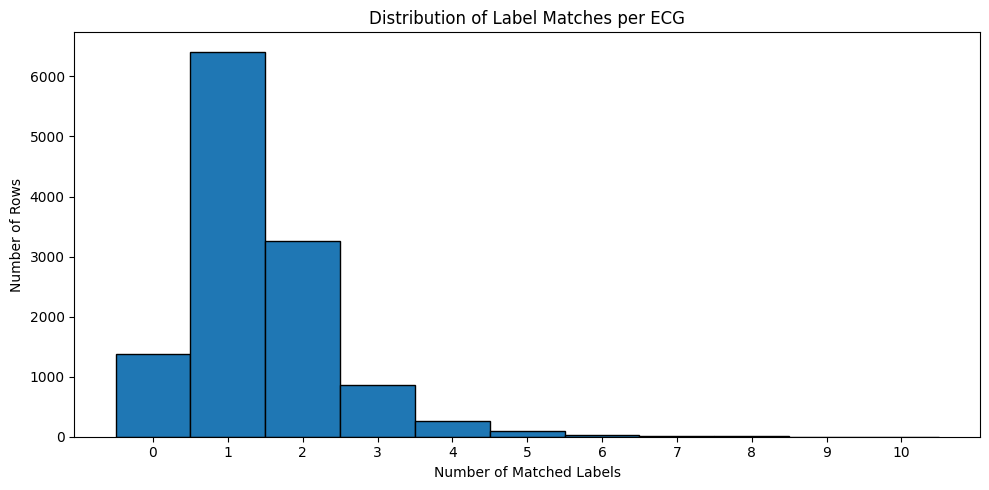

In [21]:
# Count matches per row
ecg_df['label_count'] = ecg_df['label'].apply(lambda x: x.sum())

# Summary stats
print("=== LABEL COUNT SUMMARY ===")
print(ecg_df['label_count'].value_counts().sort_index())
print(f"\nTotal rows: {len(ecg_df)}")
print(f"Zero matches:     {(ecg_df['label_count'] == 0).sum()}")
print(f"Single match:     {(ecg_df['label_count'] == 1).sum()}")
print(f"Multiple matches: {(ecg_df['label_count'] > 1).sum()}")

# Histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ecg_df['label_count'].hist(bins=range(0, ecg_df['label_count'].max() + 2), edgecolor='black', align='left')
plt.xlabel('Number of Matched Labels')
plt.ylabel('Number of Rows')
plt.title('Distribution of Label Matches per ECG')
plt.xticks(range(0, ecg_df['label_count'].max() + 1))
plt.grid(False)
plt.tight_layout()
plt.show()

## Data Analysis

In [33]:
zero_label_rows = ecg_df[ecg_df['label'].apply(lambda x: x.sum() == 0)]
print(f"Rows with no label match: {len(zero_label_rows)}")
print(zero_label_rows['Disease_desc'].value_counts().head(10))

Rows with no label match: 1377
Disease_desc
Abnormal Q wave                                        181
F60+Modifier310                                        168
L145+Modifier362                                       145
F60+Modifier308                                        141
Sinoatrial node to atrial internal migratory rhythm    112
D30+Modifier308                                        108
D30+Modifier310                                        101
Prominent U waves                                       78
Atrial escape complex(es)                               62
L147+Modifier367                                        27
Name: count, dtype: int64


In [34]:
import pandas as pd
import plotly.express as px

# split disease labels
disease_series = ecg_df['Disease_desc'].str.split(';').explode().str.strip()

disease_counts = disease_series.value_counts().reset_index()
disease_counts.columns = ['Disease', 'Count']

fig = px.bar(
    disease_counts.head(20),
    x='Disease',
    y='Count',
    title='Top 20 ECG Disease Labels',
)

fig.show()

In [35]:
fig = px.pie(
    disease_counts.head(10),
    names='Disease',
    values='Count',
    title='Top 10 Disease Distribution'
)

fig.show()

In [36]:
ecg_df['num_labels'] = ecg_df['Disease_desc'].str.split(';').apply(len)

fig = px.histogram(
    ecg_df,
    x='num_labels',
    nbins=10,
    title='Number of Labels per ECG'
)

fig.show()

In [37]:
fig = px.histogram(
    ecg_df,
    x='Gender',
    title='Gender Distribution'
)

fig.show()

In [38]:
top_diseases = disease_counts.head(10)['Disease']

df_exp = ecg_df.copy()
df_exp['Disease'] = df_exp['Disease_desc'].str.split(';')
df_exp = df_exp.explode('Disease')

df_exp = df_exp[df_exp['Disease'].isin(top_diseases)]

fig = px.histogram(
    df_exp,
    x='Disease',
    color='Gender',
    barmode='group',
    title='Top Diseases by Gender'
)

fig.show()

In [39]:
ecg_df['Age_days'] = ecg_df['Age'].str.replace('d','').astype(int)
ecg_df['Age_years'] = ecg_df['Age_days'] / 365

fig = px.histogram(
    ecg_df,
    x='Age_years',
    nbins=40,
    title='Age Distribution (Years)'
)

fig.show()

In [40]:
fig = px.histogram(
    ecg_df,
    x='Sampling_point',
    title='ECG Signal Length Distribution'
)

fig.show()

In [42]:
from itertools import combinations
from collections import Counter

pairs = Counter()

for labels in ecg_df['Disease_desc'].str.split(';'):
    labels = [l.strip() for l in labels]
    pairs.update(combinations(sorted(labels), 2))

pair_df = pd.DataFrame(pairs.items(), columns=['Pair', 'Count'])
pair_df[['Disease1','Disease2']] = pd.DataFrame(pair_df['Pair'].tolist())

fig = px.scatter(
    pair_df.head(30),
    x='Disease1',
    y='Disease2',
    size='Count',
    title='Disease Co-occurrence'
)

fig.show()

In [43]:
import pandas as pd
import plotly.express as px

# explode disease labels
disease_series = (
    ecg_df['Disease_desc']
    .str.split(';')
    .explode()
    .str.strip()
)

disease_counts = disease_series.value_counts()
import numpy as np
import plotly.graph_objects as go

top_n = 25
top_diseases = disease_counts.head(top_n)

# reshape for heatmap
z = np.array(top_diseases.values).reshape(1, -1)

fig = go.Figure(
    data=go.Heatmap(
        z=z,
        x=top_diseases.index,
        y=['Frequency'],
        colorscale='Reds',
        hovertemplate="Disease: %{x}<br>Count: %{z}<extra></extra>"
    )
)

fig.update_layout(
    title="ECG Label Imbalance Heatmap (Top 25 Diseases)",
    xaxis_title="Disease Label",
    yaxis_title="",
    height=300
)

fig.show()

## Evaluation with ECG Foundation model

In [34]:
import numpy as np
import pandas as pd
import os
import json
import wfdb
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.interpolate import interp1d
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import tqdm
from net1d import Net1D
from util import eval_with_dynamic_thresh

In [35]:
ecg_path   = 'C:/Users/zoorab/Desktop/zoher/University/Projects/Zhengzhou_ECG/Child_ecg/'
saved_dir  = './res/eval'
tasks_path = './tasks.txt'
batch_size = 32

os.makedirs(saved_dir, exist_ok=True)

# Load tasks
tasks = []
with open(tasks_path, 'r') as f:
    for line in f:
        tasks.append(line.strip())

print(f"Number of tasks: {len(tasks)}")
print(f"First 5 tasks: {tasks[:5]}")



Number of tasks: 150
First 5 tasks: ['ABNORMAL ECG', 'NORMAL SINUS RHYTHM', 'NORMAL ECG', 'SINUS RHYTHM', 'SINUS BRADYCARDIA']


In [36]:
   import os

   sample_filename = ecg_df['Filename'].iloc[0]  # e.g. 'P00/P00002/P00002_E01'
   full_path = os.path.join(ecg_path, sample_filename)

   print("Full base path:", full_path)
   print(".hea exists:", os.path.exists(full_path + '.hea'))
   print(".dat exists:", os.path.exists(full_path + '.dat'))

Full base path: C:/Users/zoorab/Desktop/zoher/University/Projects/Zhengzhou_ECG/Child_ecg/P00/P00002/P00002_E01
.hea exists: True
.dat exists: True


In [37]:
class ECG_Dataset(torch.utils.data.Dataset):
    def __init__(self, ecg_path, df):
        self.data = df.copy()
        self.data = self.data[self.data['label'].apply(lambda x: np.array(x).sum() > 0)].reset_index(drop=True)
        self.ecg_path = ecg_path
        self.target_fs = 5000  # model expects 5000

    def z_score_normalization(self, signal):
        return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

    def resample_unequal(self, ts, fs_in, fs_out):
        if fs_in == 0 or len(ts) == 0:
            return ts
        t = ts.shape[1] / fs_in
        fs_in, fs_out = int(fs_in), int(fs_out)
        if fs_out == fs_in:
            return ts
        if 2 * fs_out == fs_in:
            return ts[:, ::2]
        resampled_ts = np.zeros((ts.shape[0], fs_out))
        x_old = np.linspace(0, t, num=ts.shape[1], endpoint=True)
        x_new = np.linspace(0, t, num=int(fs_out), endpoint=True)
        for i in range(ts.shape[0]):
            f = interp1d(x_old, ts[i, :], kind='linear')
            resampled_ts[i, :] = f(x_new)
        return resampled_ts

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        label = torch.tensor(row['label'], dtype=torch.float)
        file_path = os.path.join(self.ecg_path, row['Filename'])
        sample_rate = row['Sampling_point']

        try:
            data, meta = wfdb.rdsamp(file_path)       # (samples, 12)
            data = np.transpose(data, (1, 0))          # (12, samples)
            data = self.z_score_normalization(data)
            data = self.resample_unequal(data, sample_rate, self.target_fs)
            signal = torch.FloatTensor(data)           # (12, 5000)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            signal = torch.zeros((12, self.target_fs))

        return signal, label

print("Dataset class defined.")

Dataset class defined.


In [38]:
from sklearn.model_selection import train_test_split
from tqdm import tqdm

test_df = ecg_df

dataset    = ECG_Dataset(ecg_path=ecg_path, df=test_df)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)


In [49]:
failed = []
for idx in tqdm(range(len(dataset)), desc="Validating samples"):
    try:
        signal, label = dataset[idx]
        if signal.sum() == 0:
            raise ValueError(f"Signal is all zeros (likely a load failure)")
    except Exception as e:
        row = dataset.data.iloc[idx]
        full_path = ecg_path + row['Filename']
        failed.append((idx, row['ECG_ID'], full_path, str(e)))

if failed:
    print(f"\n❌ Failed to load {len(failed)} samples:")
    for idx, ecg_id, full_path, err in failed:
        print(f"  idx={idx} | ECG_ID={ecg_id}")
        print(f"  path={full_path}")
        print(f"  .hea exists: {os.path.exists(full_path + '.hea')}")
        print(f"  error: {err}\n")
    raise RuntimeError(f"{len(failed)} samples failed to load.")
else:
    print(f"\n✅ All {len(dataset)} samples loaded successfully.")

Validating samples: 100%|██████████| 10957/10957 [02:14<00:00, 81.23it/s] 


❌ Failed to load 1 samples:
  idx=2221 | ECG_ID=P02233_E02
  path=C:/Users/zoorab/Desktop/zoher/University/Projects/Zhengzhou_ECG/Child_ecg/P02/P02233/P02233_E02
  .hea exists: True
  error: Signal is all zeros (likely a load failure)



RuntimeError: 1 samples failed to load.

In [39]:

# --- Sanity check one batch ---
signal, label = next(iter(dataloader))
print(f"\nSignal shape: {signal.shape}")   # (batch, 12, 5000)
print(f"Label shape : {label.shape}")      # (batch, 150)


Signal shape: torch.Size([32, 12, 5000])
Label shape : torch.Size([32, 150])


In [40]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Net1D(
    in_channels=12,
    base_filters=64,
    ratio=1,
    filter_list=[64, 160, 160, 400, 400, 1024, 1024],
    m_blocks_list=[2, 2, 2, 3, 3, 4, 4],
    kernel_size=16,
    stride=2,
    groups_width=16,
    verbose=False,
    use_bn=False,
    use_do=False,
    n_classes=150
)

checkpoint = torch.load(
    '12_lead_ECGFounder.pth',
    map_location=device,
    weights_only=False   # <-- add this
)
state_dict = checkpoint['state_dict']
log = model.load_state_dict(state_dict, strict=False)

print(f"Model load log: {log}")

for name, param in model.named_parameters():
    param.requires_grad = False

model.to(device)
model.eval()
print("Model loaded and ready.")

Using device: cuda:0
Model load log: <All keys matched successfully>
Model loaded and ready.


In [41]:
all_gt        = []
all_pred_prob = []

with torch.no_grad():
    for batch_idx, (input_x, input_y) in enumerate(tqdm(dataloader, desc="Inference")):
        input_x = input_x.to(device)
        input_y = input_y.to(device)
        logits  = model(input_x)
        pred    = torch.sigmoid(logits)
        all_pred_prob.append(pred.cpu().numpy())
        all_gt.append(input_y.cpu().numpy())

all_pred_prob = np.concatenate(all_pred_prob)   # (N, 150)
all_gt        = np.concatenate(all_gt)          # (N, 150)

print(f"Predictions shape : {all_pred_prob.shape}")
print(f"Ground truth shape: {all_gt.shape}")

Inference: 100%|██████████| 343/343 [02:14<00:00,  2.54it/s]

Predictions shape : (10957, 150)
Ground truth shape: (10957, 150)


In [42]:
df_gt   = pd.DataFrame(all_gt)
df_pred = pd.DataFrame(all_pred_prob)

df_gt.to_csv(os.path.join(saved_dir,   'all_gt.csv'),   index=False, float_format='%.5f')
df_pred.to_csv(os.path.join(saved_dir, 'all_pred.csv'), index=False, float_format='%.5f')

print("Saved all_gt.csv and all_pred.csv")
print(df_pred.head())

Saved all_gt.csv and all_pred.csv
        0         1         2         3         4         5         6    \
0  0.684827  0.479676  0.007319  0.593356  0.121564  0.100146  0.365509   
1  0.885498  0.577977  0.062831  0.804821  0.172409  0.253392  0.497827   
2  0.783702  0.758399  0.122426  0.881256  0.166684  0.095150  0.571849   
3  0.868898  0.234696  0.066088  0.603073  0.129412  0.146408  0.147282   
4  0.258224  0.106731  0.020428  0.381179  0.006915  0.055266  0.216161   

        7         8         9    ...       140       141       142       143  \
0  0.009692  0.044047  0.241738  ...  0.007461  0.048571  0.031308  0.032381   
1  0.035600  0.131391  0.507366  ...  0.005640  0.049175  0.072904  0.025707   
2  0.028856  0.042921  0.592884  ...  0.000725  0.024373  0.024478  0.050678   
3  0.032354  0.168440  0.511596  ...  0.006715  0.356039  0.011159  0.005783   
4  0.029345  0.015562  0.300533  ...  0.005143  0.063381  0.012045  0.001025   

        144       145       146   

In [43]:
res_test, res_test_auroc, res_test_sens, res_test_spec, res_test_f1, optimal_thresholds = \
    eval_with_dynamic_thresh(all_gt, all_pred_prob)

all_thre_df = []
for i, task in enumerate(tasks):
    all_thre_df.append([task, res_test_auroc[i], res_test_sens[i], res_test_spec[i], res_test_f1[i], optimal_thresholds[i]])

columns     = ['Field_ID', 'AUROC', 'sensitivity', 'specificity', 'f1', 'optimal_thresholds']
all_thre_df = pd.DataFrame(all_thre_df, columns=columns)
all_thre_df.to_csv(os.path.join(saved_dir, 'res_thre.csv'), index=False, float_format='%.5f')

print(all_thre_df.head(10))

                          Field_ID     AUROC  sensitivity  specificity  \
0                     ABNORMAL ECG       NaN     0.000000     0.982477   
1              NORMAL SINUS RHYTHM       NaN     0.000000     0.987314   
2                       NORMAL ECG  0.547853     0.164866     0.906719   
3                     SINUS RHYTHM       NaN     0.000000     0.968696   
4                SINUS BRADYCARDIA  0.632108     0.551872     0.647476   
5              ATRIAL FIBRILLATION  0.711372     0.600000     0.774607   
6                SINUS TACHYCARDIA  0.414608     0.027602     0.981479   
7             otherwise normal ecg  0.531805     0.814815     0.234810   
8              LEFT AXIS DEVIATION  0.927536     0.925926     0.818949   
9  PREMATURE VENTRICULAR COMPLEXES  0.708291     0.666667     0.909415   

         f1  optimal_thresholds  
0  0.000000                0.99  
1  0.000000                0.99  
2  0.199518                0.33  
3  0.000000                0.99  
4  0.207063    

In [45]:
def calculate_performance_metrics(true, pred, threshold):
    true        = np.array(true)
    pred        = np.array(pred)
    pred_binary = (pred >= threshold).astype(int)
    tp = np.sum((true == 1) & (pred_binary == 1))
    fp = np.sum((true == 0) & (pred_binary == 1))
    tn = np.sum((true == 0) & (pred_binary == 0))
    fn = np.sum((true == 1) & (pred_binary == 0))
    sens      = tp / (tp + fn)   if (tp + fn) > 0   else 0
    spec      = tn / (tn + fp)   if (tn + fp) > 0   else 0
    precision = tp / (tp + fp)   if (tp + fp) > 0   else 0
    npv       = tn / (tn + fn)   if (tn + fn) > 0   else 0
    f1        = 2 * (precision * sens) / (precision + sens) if (precision + sens) > 0 else 0
    auroc     = roc_auc_score(true, pred)          if len(np.unique(true)) > 1 else np.nan
    auprc     = average_precision_score(true, pred) if len(np.unique(true)) > 1 else np.nan
    return sens, spec, precision, f1, precision, npv, auroc, auprc

def bootstrap_ci(metric_func, true, pred, threshold, n_resamples=100):
    true, pred = np.array(true), np.array(pred)
    dist = []
    for _ in range(n_resamples):
        idx     = np.random.choice(len(true), len(true), replace=True)
        val     = metric_func(true[idx], pred[idx], threshold)
        dist.append(val)
    return (round(np.percentile(dist, 2.5), 3), round(np.percentile(dist, 97.5), 3))

# reload saved csvs (or use in-memory arrays)
all_gt_df   = pd.DataFrame(all_gt).T
all_pred_df = pd.DataFrame(all_pred_prob).T
thresholds  = all_thre_df['optimal_thresholds'].values

results = []
for i, task in enumerate(tqdm(tasks, desc="Computing metrics")):
    true      = all_gt_df.loc[i]
    pred      = all_pred_df.loc[i]
    threshold = thresholds[i]
    sens, spec, prec, f1, ppv, npv, auroc, auprc = calculate_performance_metrics(true, pred, threshold)
    results.append({
        'Label':           task,
        'Sensitivity':     round(sens,  3), 'Sensitivity_CI': bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[0], true, pred, threshold),
        'Specificity':     round(spec,  3), 'Specificity_CI': bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[1], true, pred, threshold),
        'F1':              round(f1,    3), 'F1_CI':          bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[3], true, pred, threshold),
        'PPV':             round(ppv,   3), 'PPV_CI':         bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[4], true, pred, threshold),
        'NPV':             round(npv,   3), 'NPV_CI':         bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[5], true, pred, threshold),
        'AUROC':           round(auroc, 3) if not np.isnan(auroc) else np.nan,
        'AUROC_CI':        bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[6], true, pred, threshold),
        'AUPRC':           round(auprc, 3) if not np.isnan(auprc) else np.nan,
        'AUPRC_CI':        bootstrap_ci(lambda t,p,th: calculate_performance_metrics(t,p,th)[7], true, pred, threshold),
    })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(saved_dir, 'res.csv'), index=False)
print(results_df.head(10))

Computing metrics: 100%|██████████| 150/150 [04:02<00:00,  1.62s/it]

                             Label  Sensitivity  Sensitivity_CI  Specificity  \
0                     ABNORMAL ECG        0.000      (0.0, 0.0)        0.982   
1              NORMAL SINUS RHYTHM        0.000      (0.0, 0.0)        0.987   
2                       NORMAL ECG        0.165  (0.147, 0.184)        0.907   
3                     SINUS RHYTHM        0.000      (0.0, 0.0)        0.969   
4                SINUS BRADYCARDIA        0.552  (0.525, 0.578)        0.647   
5              ATRIAL FIBRILLATION        0.600  (0.422, 0.812)        0.775   
6                SINUS TACHYCARDIA        0.028  (0.021, 0.034)        0.981   
7             otherwise normal ecg        0.815   (0.78, 0.842)        0.235   
8              LEFT AXIS DEVIATION        0.926  (0.855, 0.983)        0.819   
9  PREMATURE VENTRICULAR COMPLEXES        0.667      (0.0, 1.0)        0.909   

   Specificity_CI     F1           F1_CI    PPV          PPV_CI    NPV  \
0   (0.98, 0.985)  0.000      (0.0, 0.0)  0.0

In [52]:
results_df_filtered = results_df[(results_df['AUROC'].notna())]
results_df_filtered = results_df_filtered[
    results_df_filtered["AUROC_CI"].apply(lambda x: not (np.isnan(x[0]) and np.isnan(x[1])))
]

In [ ]:
# Build lookup: tasks_label (uppercase) → match_type
match_type_lookup = dict(zip(
    mapping_df['tasks_label'].str.upper().str.strip(),
    mapping_df['match_type']
))

# Count samples per label
label_counts = []
for i, task in enumerate(tasks):
    label_counts.append({
        'Label':      task,
        'n_positive': int(np.sum(all_gt[:, i])),
        'match_type': match_type_lookup.get(task.upper().strip(), 'Unmapped')
    })

label_counts_df = pd.DataFrame(label_counts)

# Merge into results_df_filtered
results_df_filtered = results_df_filtered.merge(label_counts_df, on='Label', how='left')

# Move key columns to front
cols = ['Label', 'n_positive', 'match_type'] + [
    c for c in results_df_filtered.columns
    if c not in ['Label', 'n_positive', 'match_type']
]
results_df_filtered = results_df_filtered[cols]

In [75]:
partial_df# define the labels you want to inspect
target_labels = ['PREMATURE SUPRAVENTRICULAR COMPLEXES', 'NONSPECIFIC ST ABNORMALITY']

# get their indices from tasks list
target_indices = {label: tasks.index(label) for label in target_labels}
print(f"Label indices: {target_indices}")

# filter ecg_df for each label separately
for label, idx in target_indices.items():
    samples = ecg_df[ecg_df['label'].apply(lambda vec: vec[idx] == 1)]
    print(f"\n=== {label} — {len(samples)} samples ===")
    display(samples[['AHA_code', 'Disease_desc', 'dominant_match_type','matched_types']])

Label indices: {'PREMATURE SUPRAVENTRICULAR COMPLEXES': 19, 'NONSPECIFIC ST ABNORMALITY': 25}

=== PREMATURE SUPRAVENTRICULAR COMPLEXES — 16 samples ===


,AHA_code,Disease_desc,dominant_match_type,matched_types
1885,'C21';'D36';'Abnormal Q wave',Sinus tachycardia; Junctional premature comple...,Exact,"[Exact, Close]"
3355,'D36';'F60+Modifier308';'I106';'Abnormal preco...,Junctional premature complex(es); F60+Modifier...,Exact,"[Close, Exact, Exact, Exact, Exact]"
3358,'D36';'F60+Modifier310';'I106';'Abnormal preco...,Junctional premature complex(es); F60+Modifier...,Exact,"[Close, Exact, Exact, Exact, Exact, Exact, Exa..."
3360,'D36';'I106';'Abnormal precordial R-wave progr...,Junctional premature complex(es); Right bundle...,Exact,"[Close, Exact, Exact, Exact, Exact, Exact, Close]"
4987,'D36',Junctional premature complex(es),Close,[Close]
5173,'D36',Junctional premature complex(es),Close,[Close]
5920,'D36',Junctional premature complex(es),Close,[Close]
6795,'D36',Junctional premature complex(es),Close,[Close]
6824,'D36',Junctional premature complex(es),Close,[Close]
8935,'D36',Junctional premature complex(es),Close,[Close]



=== NONSPECIFIC ST ABNORMALITY — 326 samples ===


,AHA_code,Disease_desc,dominant_match_type,matched_types
27,'C21';'L145';'Suggests210',Sinus tachycardia; ST deviation; Hypocalcemia,Exact,"[Exact, Close]"
28,'C21';'J125';'L145';'L146';'L148';'Prolonged Q...,Sinus tachycardia; Low voltage; ST deviation; ...,Exact,"[Exact, Exact, Close, Close, Exact, Close]"
839,'C21';'L145';'Suggests210',Sinus tachycardia; ST deviation; Hypocalcemia,Exact,"[Exact, Close]"
1083,'C21';'K141';'K142';'L145';'L146',Sinus tachycardia; Right atrial enlargement; L...,Exact,"[Exact, Exact, Exact, Close, Close]"
1575,'C21';'F60+Modifier310';'L145';'Abnormal Q wave',Sinus tachycardia; F60+Modifier310; ST deviati...,Exact,"[Exact, Close]"
...,...,...,...,...
13952,'C21';'L145';'L147';'Suggests208';'Suggests210',Sinus tachycardia; ST deviation; T-wave abnorm...,Exact,"[Exact, Close, Exact]"
13965,'C23';'Left ventricular high voltage';'L145';'...,Sinus arrhythmia; Left ventricular high voltag...,Close,"[Close, Close, Close]"
14032,'L145';'L148';'Suggests210',ST deviation; Prolonged QT interval; Hypocalcemia,Exact,"[Close, Exact]"
14073,'L145',ST deviation,Close,[Close]


In [54]:
results_df_filtered

,Label,n_positive,match_type,Sensitivity,Sensitivity_CI,Specificity,Specificity_CI,F1,F1_CI,PPV,PPV_CI,NPV,NPV_CI,AUROC,AUROC_CI,AUPRC,AUPRC_CI
0,NORMAL ECG,1759,Exact,0.165,"(0.147, 0.184)",0.907,"(0.902, 0.912)",0.200,"(0.186, 0.22)",0.253,"(0.23, 0.273)",0.850,"(0.843, 0.857)",0.548,"(0.534, 0.561)",0.201,"(0.19, 0.216)"
1,SINUS BRADYCARDIA,935,Exact,0.552,"(0.525, 0.578)",0.647,"(0.638, 0.658)",0.207,"(0.19, 0.22)",0.127,"(0.115, 0.136)",0.939,"(0.934, 0.944)",0.632,"(0.614, 0.657)",0.134,"(0.124, 0.151)"
2,ATRIAL FIBRILLATION,25,Exact,0.600,"(0.422, 0.812)",0.775,"(0.767, 0.784)",0.012,"(0.006, 0.017)",0.006,"(0.003, 0.009)",0.999,"(0.998, 1.0)",0.711,"(0.578, 0.796)",0.009,"(0.003, 0.023)"
3,SINUS TACHYCARDIA,2210,Exact,0.028,"(0.021, 0.034)",0.981,"(0.979, 0.984)",0.050,"(0.039, 0.064)",0.274,"(0.216, 0.332)",0.800,"(0.793, 0.809)",0.415,"(0.404, 0.428)",0.185,"(0.177, 0.195)"
4,otherwise normal ecg,621,Exact,0.815,"(0.78, 0.842)",0.235,"(0.227, 0.244)",0.112,"(0.104, 0.12)",0.060,"(0.054, 0.065)",0.955,"(0.946, 0.961)",0.532,"(0.513, 0.549)",0.062,"(0.055, 0.07)"
5,LEFT AXIS DEVIATION,54,Exact,0.926,"(0.855, 0.983)",0.819,"(0.811, 0.826)",0.048,"(0.039, 0.06)",0.025,"(0.018, 0.031)",1.000,"(0.999, 1.0)",0.928,"(0.904, 0.946)",0.045,"(0.031, 0.075)"
6,PREMATURE VENTRICULAR COMPLEXES,6,Exact,0.667,"(0.0, 1.0)",0.909,"(0.904, 0.914)",0.008,"(0.002, 0.016)",0.004,"(0.0, 0.008)",1.000,"(0.999, 1.0)",0.708,"(0.441, 0.971)",0.004,"(0.0, 0.017)"
7,RIGHT BUNDLE BRANCH BLOCK,290,Exact,0.907,"(0.874, 0.94)",0.808,"(0.8, 0.815)",0.202,"(0.18, 0.22)",0.114,"(0.101, 0.128)",0.997,"(0.995, 0.998)",0.919,"(0.906, 0.93)",0.258,"(0.204, 0.309)"
8,LEFT ATRIAL ENLARGEMENT,184,Exact,0.815,"(0.765, 0.88)",0.277,"(0.269, 0.285)",0.037,"(0.031, 0.042)",0.019,"(0.016, 0.022)",0.989,"(0.985, 0.993)",0.519,"(0.486, 0.557)",0.020,"(0.016, 0.034)"
9,NONSPECIFIC T WAVE ABNORMALITY,2544,Exact,0.493,"(0.47, 0.511)",0.646,"(0.637, 0.657)",0.370,"(0.356, 0.383)",0.297,"(0.285, 0.311)",0.808,"(0.798, 0.818)",0.591,"(0.579, 0.602)",0.326,"(0.31, 0.344)"


In [57]:
import plotly.express as px
import pandas as pd

# make a copy
df = results_df_filtered.copy()

# unpack CI tuples
df[['AUROC_low', 'AUROC_high']] = pd.DataFrame(df['AUROC_CI'].tolist(), index=df.index)

# error bars
df['AUROC_err_low']  = df['AUROC'] - df['AUROC_low']
df['AUROC_err_high'] = df['AUROC_high'] - df['AUROC']

# log-scale size so rare classes are still visible (not invisible dots)
df['bubble_size'] = np.log1p(df['n_positive'])

# sort by AUROC
df_sorted = df.sort_values('AUROC')

# color order for legend
match_order   = ['Exact', 'Close', 'Partial', 'Unmapped']
match_palette = {
    'Exact':    '#1D9E75',   # teal  - fully trusted label
    'Close':    '#EF9F27',   # amber - minor wording diff
    'Partial':  '#378ADD',   # blue  - concept overlap only
    'Unmapped': '#E24B4A',   # red   - no ECGCode equivalent
}

fig = px.scatter(
    df_sorted,
    x='AUROC',
    y='Label',
    error_x='AUROC_err_high',
    error_x_minus='AUROC_err_low',
    color='match_type',
    color_discrete_map=match_palette,
    category_orders={'match_type': match_order},
    size='bubble_size',
    size_max=18,
    title='AUROC per ECG Label — bubble size = log(n_positive), color = label quality',
    hover_data={
        'AUROC':          ':.3f',
        'AUROC_low':      ':.3f',
        'AUROC_high':     ':.3f',
        'n_positive':      True,
        'match_type':     True,
        'bubble_size':    False,   # hide the derived column from tooltip
    }
)

fig.update_layout(
    height=max(600, len(df_sorted) * 18),   # auto-scale height to number of labels
    xaxis_title='AUROC',
    yaxis_title='',
    xaxis=dict(range=[0, 1]),
    legend_title='Label quality',
    legend=dict(orientation='h', y=1.02, x=0),
    margin=dict(l=20, r=20, t=60, b=40),
)

# reference line at 0.5 (chance)
fig.add_vline(
    x=0.5,
    line_dash='dash',
    line_color='gray',
    opacity=0.5,
    annotation_text='chance',
    annotation_position='top'
)

fig.show()

# how many unique labels exist in your data
label_counts = np.array(ecg_df['label'].tolist()).sum(axis=0)
label_df = pd.DataFrame({'Label': labels, 'Count': label_counts.astype(int)})
label_df = label_df[label_df['Count'] > 0].sort_values('Count', ascending=False)

print(f"Total labels with at least 1 sample: {len(label_df)}")
print(label_df.to_string())

In [78]:
ecg_df

,Filename,ECG_ID,Patient_ID,Age,Gender,Acquisition_date,Sampling_point,Lead,AHA_code,CHN_code,ICD-10 code,pSQI,basSQI,bSQI,Disease_desc,label,matched_types,dominant_match_type,label_count
1,P00/P00002/P00002_E01,P00002_E01,P00002,4327d,'Male',2017-11-28 21:59:47,15000,12,'C21','C13','I51.4';'J18.9','I':0.472;'II':0.446;'III':0.449;'aVR':0.484;'...,'I':0.995;'II':0.980;'III':0.992;'aVR':0.992;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
2,P00/P00003/P00003_E01,P00003_E01,P00003,1087d,'Female',2017-11-29 16:04:57,10000,12,'C21','C13','Q21.0';'Q24.9','I':0.495;'II':0.347;'III':0.340;'aVR':0.382;'...,'I':0.915;'II':0.895;'III':0.882;'aVR':0.908;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
5,P00/P00005/P00005_E01,P00005_E01,P00005,857d,'Male',2017-12-09 09:58:20,15000,12,'C21';'First-degree AV block';'L147','C13';'H74';'L123','Q21.1';'Q24.9','I':0.320;'II':0.363;'III':0.347;'aVR':0.334;'...,'I':0.971;'II':0.964;'III':0.992;'aVR':0.966;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia; First-degree AV block; T-wa...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...","[Exact, Exact, Exact]",Exact,3
7,P00/P00006/P00006_E01,P00006_E01,P00006,889d,'Female',2017-12-10 07:38:42,15000,12,'D37';'H83';'I105';'L155','D28';'H75';'I86';'L133','Q21.0','I':0.350;'II':0.412;'III':0.267;'aVR':0.407;'...,'I':0.996;'II':0.990;'III':0.995;'aVR':0.994;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Junctional escape complex(es); Second-degree A...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Exact, Exact, Exact]",Exact,3
8,P00/P00006/P00006_E02,P00006_E02,P00006,889d,'Female',2017-12-10 00:41:53,15000,12,'D37';'H84';'Left ventricular high voltage';'L...,'D28';'H76';'J106';'L133','Q21.0','I':0.348;'II':0.450;'III':0.259;'aVR':0.404;'...,'I':0.992;'II':0.987;'III':0.992;'aVR':0.990;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Junctional escape complex(es); Second-degree A...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Exact, Close, Exact]",Exact,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14185,P11/P11639/P11639_E01,P11639_E01,P11639,2646d,'Male',2021-06-24 18:22:31,10000,12,'A1','A1','J35.3','I':0.330;'II':0.422;'III':0.387;'aVR':0.377;'...,'I':0.991;'II':0.991;'III':0.981;'aVR':0.992;'...,'I':1.000;'II':1.000;'III':0.990;'aVR':1.000;'...,Normal ECG,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
14186,P11/P11640/P11640_E01,P11640_E01,P11640,657d,'Male',2021-07-01 09:47:16,10500,12,'C21';'L147','C13';'L123','S02.0';'S06.5';'S06.6';'S06.7';'T14.0','I':0.284;'II':0.362;'III':0.378;'aVR':0.332;'...,'I':0.919;'II':0.934;'III':0.939;'aVR':0.929;'...,'I':0.976;'II':0.993;'III':1.000;'aVR':0.993;'...,Sinus tachycardia; T-wave abnormality,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...","[Exact, Exact]",Exact,2
14187,P11/P11641/P11641_E01,P11641_E01,P11641,1484d,'Female',2021-07-04 21:58:36,15000,12,'D30+Modifier310','D21+Frequent','I49.1';'R53','I':0.387;'II':0.387;'III':0.411;'aVR':0.384;'...,'I':0.985;'II':0.975;'III':0.960;'aVR':0.980;'...,'I':0.994;'II':0.987;'III':0.982;'aVR':0.994;'...,D30+Modifier310,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
14188,P11/P11642/P11642_E01,P11642_E01,P11642,5178d,'Male',2021-06-27 20:22:00,15000,12,'C23';'L150','C15';'L128','J31.0';'J34.2';'S02.2','I':0.401;'II':0.409;'III':0.409;'aVR':0.407;'...,'I':0.975;'II':0.973;'III':0.974;'aVR':0.973;'...,'I':0.974;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus arrhythmia; Prominent U waves,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Close],Close,1


In [82]:
# ── Save ──────────────────────────────────────────────────────────────────────
# convert numpy arrays to lists before saving
ecg_df_save = ecg_df.copy()
ecg_df_save['label'] = ecg_df_save['label'].apply(lambda v: json.dumps(v.tolist()))
ecg_df_save.to_csv('ecg_df.csv', index=False)


In [83]:
ecg_df

,Filename,ECG_ID,Patient_ID,Age,Gender,Acquisition_date,Sampling_point,Lead,AHA_code,CHN_code,ICD-10 code,pSQI,basSQI,bSQI,Disease_desc,label,matched_types,dominant_match_type,label_count
1,P00/P00002/P00002_E01,P00002_E01,P00002,4327d,'Male',2017-11-28 21:59:47,15000,12,'C21','C13','I51.4';'J18.9','I':0.472;'II':0.446;'III':0.449;'aVR':0.484;'...,'I':0.995;'II':0.980;'III':0.992;'aVR':0.992;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
2,P00/P00003/P00003_E01,P00003_E01,P00003,1087d,'Female',2017-11-29 16:04:57,10000,12,'C21','C13','Q21.0';'Q24.9','I':0.495;'II':0.347;'III':0.340;'aVR':0.382;'...,'I':0.915;'II':0.895;'III':0.882;'aVR':0.908;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
5,P00/P00005/P00005_E01,P00005_E01,P00005,857d,'Male',2017-12-09 09:58:20,15000,12,'C21';'First-degree AV block';'L147','C13';'H74';'L123','Q21.1';'Q24.9','I':0.320;'II':0.363;'III':0.347;'aVR':0.334;'...,'I':0.971;'II':0.964;'III':0.992;'aVR':0.966;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus tachycardia; First-degree AV block; T-wa...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...","[Exact, Exact, Exact]",Exact,3
7,P00/P00006/P00006_E01,P00006_E01,P00006,889d,'Female',2017-12-10 07:38:42,15000,12,'D37';'H83';'I105';'L155','D28';'H75';'I86';'L133','Q21.0','I':0.350;'II':0.412;'III':0.267;'aVR':0.407;'...,'I':0.996;'II':0.990;'III':0.995;'aVR':0.994;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Junctional escape complex(es); Second-degree A...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Exact, Exact, Exact]",Exact,3
8,P00/P00006/P00006_E02,P00006_E02,P00006,889d,'Female',2017-12-10 00:41:53,15000,12,'D37';'H84';'Left ventricular high voltage';'L...,'D28';'H76';'J106';'L133','Q21.0','I':0.348;'II':0.450;'III':0.259;'aVR':0.404;'...,'I':0.992;'II':0.987;'III':0.992;'aVR':0.990;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...,Junctional escape complex(es); Second-degree A...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Exact, Close, Exact]",Exact,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14185,P11/P11639/P11639_E01,P11639_E01,P11639,2646d,'Male',2021-06-24 18:22:31,10000,12,'A1','A1','J35.3','I':0.330;'II':0.422;'III':0.387;'aVR':0.377;'...,'I':0.991;'II':0.991;'III':0.981;'aVR':0.992;'...,'I':1.000;'II':1.000;'III':0.990;'aVR':1.000;'...,Normal ECG,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Exact],Exact,1
14186,P11/P11640/P11640_E01,P11640_E01,P11640,657d,'Male',2021-07-01 09:47:16,10500,12,'C21';'L147','C13';'L123','S02.0';'S06.5';'S06.6';'S06.7';'T14.0','I':0.284;'II':0.362;'III':0.378;'aVR':0.332;'...,'I':0.919;'II':0.934;'III':0.939;'aVR':0.929;'...,'I':0.976;'II':0.993;'III':1.000;'aVR':0.993;'...,Sinus tachycardia; T-wave abnormality,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...","[Exact, Exact]",Exact,2
14187,P11/P11641/P11641_E01,P11641_E01,P11641,1484d,'Female',2021-07-04 21:58:36,15000,12,'D30+Modifier310','D21+Frequent','I49.1';'R53','I':0.387;'II':0.387;'III':0.411;'aVR':0.384;'...,'I':0.985;'II':0.975;'III':0.960;'aVR':0.980;'...,'I':0.994;'II':0.987;'III':0.982;'aVR':0.994;'...,D30+Modifier310,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[],Unmapped,0
14188,P11/P11642/P11642_E01,P11642_E01,P11642,5178d,'Male',2021-06-27 20:22:00,15000,12,'C23';'L150','C15';'L128','J31.0';'J34.2';'S02.2','I':0.401;'II':0.409;'III':0.409;'aVR':0.407;'...,'I':0.975;'II':0.973;'III':0.974;'aVR':0.973;'...,'I':0.974;'II':1.000;'III':1.000;'aVR':1.000;'...,Sinus arrhythmia; Prominent U waves,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[Close],Close,1


In [ ]:
# to do

- checking the different distrubution between CINC data and pediatric data
- reporting foundation model performance on un-matched labels
- training small model from scratch on the data
- compression (kd, prudning) + data free compression.
- plot the curve which show the auc based on the different number of samples and compare between 